# Comparing Weight-based and Weightless Neural Networks for Handwritten Digit Recognition

## 1. Setup
### Imports

In [31]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

SEEDS = [42, 123]

INPUT_SIZE = 28 * 28
NUM_CLASSES = 10

# MLP
HIDDEN1 = 256
HIDDEN2 = 128

# WiSARD
# Number of bits grouped into one RAM address
# Common values to try: 4, 8, 16
ADDRESS_SIZE = 32

In [24]:
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

In [2]:
# Dependencies for WNN package
# 1. Uninstall any broken pybind11 versions just in case
!pip uninstall -y pybind11 wisardpkg

# 2. Force the installation of an older, compatible pybind11 (v2.x)
!pip install "pybind11<3.0"

# 3. Install wisardpkg without using the cache
!pip install --no-cache-dir wisardpkg

Found existing installation: pybind11 2.13.6
Uninstalling pybind11-2.13.6:
  Successfully uninstalled pybind11-2.13.6
Found existing installation: wisardpkg 1.6.3
Uninstalling wisardpkg-1.6.3:
  Successfully uninstalled wisardpkg-1.6.3
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.5/126.5 kB 24.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for wisardpkg: filename=wisardpkg-1.6.3-cp312-cp312-linux_x86_64.whl size=3331008 sha256=e70b29ff7d8c4b44760c4282a8cdd452380b655e3b0bdda344b47e389f4e6443
  Stored in directory: /tmp/pip-ephem-wheel-cache-c_86t97c/wheels/ac/a2/68/6af3d7fbcb1c34042a3a59650c77bec73ab7dcc1048750e464
Successfully built wisardpkg


In [3]:
import wisardpkg as wnn

- In standard model, normalize data to mean and standard deviation
- In WiSARD, binarize it
- Thresholding: anything above 0.5 = 1, anything below 0.5 = 0

### Reproducibility & Device

In [14]:
# ==========================================
# Reproducibility Helper
# ==========================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### Hyperparameters

### Setting Up Dataset

In [16]:
def get_mnist_datasets(seed=42):
    """
    Params:
        seed: for reproducibility
    Returns:
        train_gray, val_gray, test_gray
        train_bin,  val_bin,  test_bin
    """
    transform_gray = transforms.Compose([
        transforms.ToTensor(),  # [0,1]
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    transform_bin = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (x > 0.5).float())
    ])

    full_train_gray = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform_gray
    )
    test_gray = datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform_gray
    )

    full_train_bin = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform_bin
    )
    test_bin = datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform_bin
    )

    train_size = int(0.9 * len(full_train_gray))
    val_size = len(full_train_gray) - train_size

    # same split sizes for both
    train_gray, val_gray = random_split(
        full_train_gray,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )

    train_bin, val_bin = random_split(
        full_train_bin,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )

    return train_gray, val_gray, test_gray, train_bin, val_bin, test_bin


def make_loaders(train_ds, val_ds, test_ds, batch_size=128):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

## 2. MLP Model

In [17]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate_torch_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    start_inf = time.perf_counter()

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    end_inf = time.perf_counter()

    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds)

    total_inf_time = end_inf - start_inf
    avg_inf_time_per_sample = total_inf_time / len(loader.dataset)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm,
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds),
        "inference_time_total_sec": total_inf_time,
        "inference_time_per_sample_sec": avg_inf_time_per_sample,
    }


def run_mlp_experiment(train_loader, val_loader, test_loader, seed=42, title="MLP"):

    torch.manual_seed(seed)
    model = MLP(INPUT_SIZE, HIDDEN1, HIDDEN2, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_acc = -1.0
    best_state = None

    train_start = time.perf_counter()

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_results = evaluate_torch_model(model, val_loader, criterion, device)
        val_acc = val_results["accuracy"]

        print(f"{title} | Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    train_end = time.perf_counter()
    training_time = train_end - train_start

    model.load_state_dict(best_state)
    test_results = evaluate_torch_model(model, test_loader, criterion, device)
    test_results["training_time_sec"] = training_time
    test_results["num_parameters"] = count_trainable_parameters(model)
    test_results["model_name"] = title

    return model, test_results

## 3. SimpleWiSARD WNN: Custom Built

In [18]:
class SimpleWiSARD:
    """
    A simple WiSARD-like classifier:
    - Input must be binary vector of shape [n_features]
    - Features are permuted once and split into RAM groups of address_size bits
    - For each class and RAM, observed addresses are stored
    - Prediction counts how many RAMs hit for each class

    This is a clean educational implementation for comparison experiments.
    """
    def __init__(self, input_size=784, num_classes=10, address_size=8, seed=42):
        self.input_size = input_size
        self.num_classes = num_classes
        self.address_size = address_size
        self.seed = seed

        self.rng = np.random.default_rng(seed)

        # Number of RAM nodes
        self.num_rams = math.ceil(input_size / address_size)

        # Pad input size if needed
        self.padded_size = self.num_rams * self.address_size
        self.padding = self.padded_size - self.input_size

        # One fixed random permutation for input mapping
        self.permutation = self.rng.permutation(self.padded_size)

        # discriminator[class_idx][ram_idx] = set(addresses seen)
        self.discriminators = [
            [set() for _ in range(self.num_rams)] for _ in range(self.num_classes)
        ]

    def _prepare_input(self, x):
        """
        x: 1D binary numpy array of shape [input_size]
        returns: permuted padded binary vector of shape [padded_size]
        """
        x = np.asarray(x).astype(np.uint8).reshape(-1)

        if len(x) != self.input_size:
            raise ValueError(f"Expected input size {self.input_size}, got {len(x)}")

        if self.padding > 0:
            x = np.concatenate([x, np.zeros(self.padding, dtype=np.uint8)])

        x = x[self.permutation]
        return x

    def _address_from_bits(self, bits):
        """
        Convert a small binary vector into integer address.
        Example: [1,0,1] -> 5
        """
        addr = 0
        for bit in bits:
            addr = (addr << 1) | int(bit)
        return addr

    def fit(self, X, y):
        """
        X: binary numpy array [N, input_size]
        y: labels [N]
        """
        total_samples = len(X)
        print(f"Starting Custom WiSARD training on {total_samples} samples...")

        for i, (xi, yi) in enumerate(zip(X, y)):
            xp = self._prepare_input(xi)

            for ram_idx in range(self.num_rams):
                start = ram_idx * self.address_size
                end = start + self.address_size
                bits = xp[start:end]
                addr = self._address_from_bits(bits)
                self.discriminators[int(yi)][ram_idx].add(addr)

            # Progress report every 10,000 samples
            if (i + 1) % 10000 == 0:
                print(f"  Processed {i + 1}/{total_samples} samples...")

        print("Custom WiSARD training complete.")

    def score_sample(self, x):
        """
        Returns class scores = number of RAM hits per class
        """
        xp = self._prepare_input(x)
        scores = np.zeros(self.num_classes, dtype=np.int32)

        for ram_idx in range(self.num_rams):
            start = ram_idx * self.address_size
            end = start + self.address_size
            bits = xp[start:end]
            addr = self._address_from_bits(bits)

            for c in range(self.num_classes):
                if addr in self.discriminators[c][ram_idx]:
                    scores[c] += 1

        return scores

    def predict(self, X):
        preds = []
        for x in X:
            scores = self.score_sample(x)
            pred = int(np.argmax(scores))
            preds.append(pred)
        return np.array(preds)

    def memory_statistics(self):
        total_addresses = 0
        per_class_addresses = []

        for c in range(self.num_classes):
            class_total = sum(len(ram_set) for ram_set in self.discriminators[c])
            per_class_addresses.append(class_total)
            total_addresses += class_total

        return {
            "num_classes": self.num_classes,
            "num_rams": self.num_rams,
            "address_size": self.address_size,
            "total_stored_addresses": total_addresses,
            "stored_addresses_per_class": per_class_addresses,
        }

### Helpers to convert datasets to numpy for WiSARD

In [19]:
def dataset_to_numpy_binary(dataset):
    """
    Converts a PyTorch dataset of tensors to:
      X: [N, 784] binary uint8
      y: [N]
    """
    X_list = []
    y_list = []

    for img, label in dataset:
        # img shape: [1, 28, 28]
        x = img.view(-1).numpy()
        x = (x > 0.5).astype(np.uint8)  # safety: enforce binary
        X_list.append(x)
        y_list.append(label)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    return X, y


def evaluate_numpy_classifier(model, X_test, y_test):
    start_inf = time.perf_counter()
    y_pred = model.predict(X_test)
    end_inf = time.perf_counter()

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    total_inf_time = end_inf - start_inf
    avg_inf_time_per_sample = total_inf_time / len(y_test)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm,
        "y_true": y_test,
        "y_pred": y_pred,
        "inference_time_total_sec": total_inf_time,
        "inference_time_per_sample_sec": avg_inf_time_per_sample,
    }


def run_wisard_experiment(train_ds, test_ds, address_size=8, seed=42, title="WiSARD"):
    X_train, y_train = dataset_to_numpy_binary(train_ds)
    X_test, y_test = dataset_to_numpy_binary(test_ds)

    model = SimpleWiSARD(
        input_size=INPUT_SIZE,
        num_classes=NUM_CLASSES,
        address_size=address_size,
        seed=seed
    )

    train_start = time.perf_counter()
    model.fit(X_train, y_train)
    train_end = time.perf_counter()

    results = evaluate_numpy_classifier(model, X_test, y_test)
    results["training_time_sec"] = train_end - train_start
    results["memory_stats"] = model.memory_statistics()
    results["model_name"] = title

    return model, results

## 4. WiSARD WNN: From Package

In [20]:
def run_wisardpkg_experiment(train_ds, test_ds, address_size=8, title="WiSARD_Pkg"):
    """
    Runs the official wisardpkg implementation to compare alongside the custom build.
    """
    # 1. Prepare data using existing helper
    X_train_np, y_train_np = dataset_to_numpy_binary(train_ds)
    X_test_np, y_test_np = dataset_to_numpy_binary(test_ds)

    # wisardpkg requires standard Python lists of ints for X, and lists of strings for y
    X_train = X_train_np.tolist()
    y_train = [str(label) for label in y_train_np]

    X_test = X_test_np.tolist()
    y_test = y_test_np # Keep as numpy array for sklearn metrics

    # 2. Initialize Model
    import wisardpkg as wnn
    model = wnn.Wisard(address_size, bleachingActivated=True)

    # 3. Train
    print(f"Starting {title} (C++ Package) training on {len(X_train)} samples...")
    train_start = time.perf_counter()
    model.train(X_train, y_train)
    train_end = time.perf_counter()

    # 4. Infer
    test_start = time.perf_counter()
    predictions_str = model.classify(X_test)
    test_end = time.perf_counter()
    print(f"{title} training complete in {train_end - train_start:.2f} seconds.")

    # Convert string predictions back to integers
    y_pred = np.array([int(p) for p in predictions_str])

    # 5. Evaluate Metrics
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred)

    total_inf_time = test_end - test_start
    avg_inf_time_per_sample = total_inf_time / len(y_test)

    results = {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm,
        "y_true": y_test,
        "y_pred": y_pred,
        "inference_time_total_sec": total_inf_time,
        "inference_time_per_sample_sec": avg_inf_time_per_sample,
        "training_time_sec": train_end - train_start,
        "model_name": title
    }

    return model, results

## 5. Hyperparameter Search - Setting Wisard Models Address Size

In [29]:
def search_address_size():
  """Iterates through different address sizes and compares results between
  wisard models to find best option."""

  # 1. Set sizes we want to try
  ADDR_SIZES = [4, 8, 12, 16, 24, 32, 40, 48, 60]

  custom_accs = []
  pkg_accs = []

  print("=" * 60)
  print("STARTING ADDRESS SIZE HYPERPARAMETER SEARCH")
  print("=" * 60)

  # 2. Grab fixed dataset split for fair comparison
  _, _, _, train_bin, _, test_bin = get_mnist_datasets(seed=42)

  # 3. Loop through sizes & evaluate
  for size in ADDR_SIZES:
      print("\n=============")
      print(f"Evaluating Address Size: {size}...")

      # Testing custom WiSARD
      _, custom_res = run_wisard_experiment(
              train_bin, test_bin,
              address_size=size,
              seed=42,
              title=f"Custom_a{size}"
          )

      custom_accs.append(custom_res['accuracy'])
      print(f"  -> Custom WiSARD Accuracy: {custom_res['accuracy']*100:.2f}%")

      # Test Package WiSARD
      _, pkg_res = run_wisardpkg_experiment(
          train_bin, test_bin,
          address_size=size,
          title=f"Pkg_a{size}"
      )
      pkg_accs.append(pkg_res['accuracy'])
      print(f"  -> Package WiSARD Accuracy: {pkg_res['accuracy']*100:.2f}%")

  # 4. Graph the Results
  plt.figure(figsize=(10, 6))

  # Plot both lines
  plt.plot(ADDR_SIZES, custom_accs, marker='o', linestyle='-', linewidth=2, label='Custom WiSARD')
  plt.plot(ADDR_SIZES, pkg_accs, marker='s', linestyle='--', linewidth=2, label='Package WiSARD (wisardpkg)')

  # Formatting the graph
  plt.title('WiSARD Model Accuracy vs. RAM Address Size', fontsize=14, fontweight='bold')
  plt.xlabel('Address Size (Bits per RAM Node)', fontsize=12)
  plt.ylabel('Test Accuracy', fontsize=12)
  plt.xticks(ADDR_SIZES) # Ensure the x-axis shows our exact test values
  plt.grid(True, linestyle=':', alpha=0.7)
  plt.legend(fontsize=12)

  # Display the graph
  plt.tight_layout()
  plt.show()


STARTING ADDRESS SIZE HYPERPARAMETER SEARCH

Evaluating Address Size: 4...
Starting Custom WiSARD training on 54000 samples...
  Processed 10000/54000 samples...
  Processed 20000/54000 samples...
  Processed 30000/54000 samples...
  Processed 40000/54000 samples...
  Processed 50000/54000 samples...
Custom WiSARD training complete.
  -> Custom WiSARD Accuracy: 16.05%
Starting Pkg_a4 (C++ Package) training on 54000 samples...
Pkg_a4 training complete in 1.69 seconds.
  -> Package WiSARD Accuracy: 73.88%

Evaluating Address Size: 8...
Starting Custom WiSARD training on 54000 samples...
  Processed 10000/54000 samples...
  Processed 20000/54000 samples...
  Processed 30000/54000 samples...
  Processed 40000/54000 samples...
  Processed 50000/54000 samples...
Custom WiSARD training complete.
  -> Custom WiSARD Accuracy: 30.82%
Starting Pkg_a8 (C++ Package) training on 54000 samples...
Pkg_a8 training complete in 1.25 seconds.
  -> Package WiSARD Accuracy: 78.22%

Evaluating Address Size: 

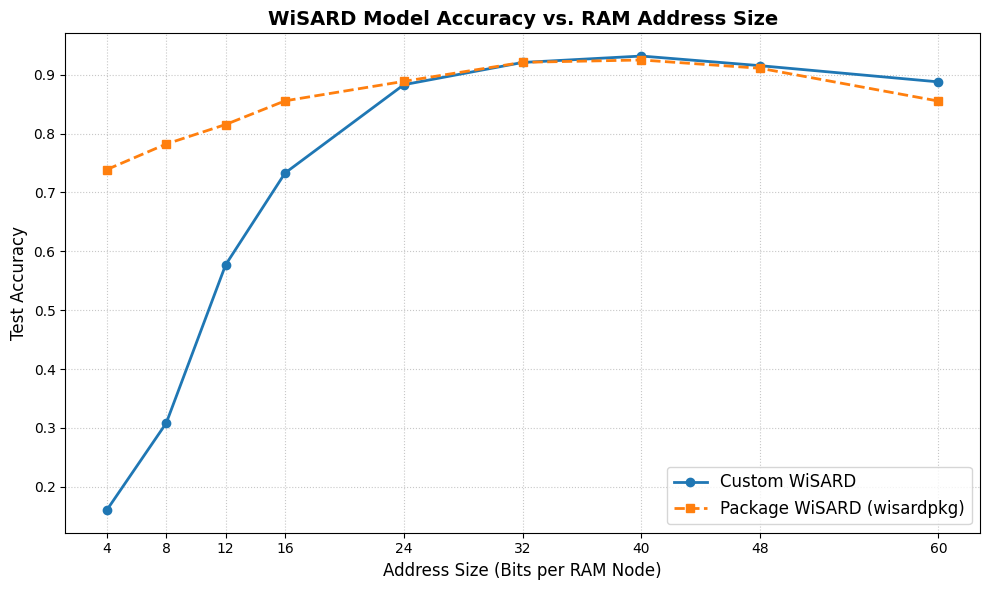

In [30]:
# Finding best address size for wisard models
search_address_size()

## 6. Running Experiment - Main

### Pretty printing

In [21]:
def aggregate_results(all_runs_results):
    summary = {}
    for run_results in all_runs_results:
        for res in run_results:
            name = res['model_name']
            if name not in summary:
                summary[name] = defaultdict(list)

            summary[name]['accuracy'].append(res['accuracy'])
            summary[name]['precision_macro'].append(res['precision_macro'])
            summary[name]['recall_macro'].append(res['recall_macro'])
            summary[name]['f1_macro'].append(res['f1_macro'])
            summary[name]['training_time_sec'].append(res['training_time_sec'])
            summary[name]['inference_time_per_sample_sec'].append(res['inference_time_per_sample_sec'])
    return summary

In [22]:
def print_results(results):
    print("\n" + "=" * 70)
    print(f"Results for: {results['model_name']}")
    print("=" * 70)
    print(f"Accuracy                 : {results['accuracy']:.4f}")
    print(f"Macro Precision          : {results['precision_macro']:.4f}")
    print(f"Macro Recall             : {results['recall_macro']:.4f}")
    print(f"Macro F1                 : {results['f1_macro']:.4f}")
    print(f"Training Time (sec)      : {results['training_time_sec']:.4f}")
    print(f"Inference Time (sec)     : {results['inference_time_total_sec']:.4f}")
    print(f"Inference / Sample (sec) : {results['inference_time_per_sample_sec']:.8f}")

    if "num_parameters" in results:
        print(f"Trainable Parameters     : {results['num_parameters']}")

    if "memory_stats" in results:
        mem = results["memory_stats"]
        print(f"WiSARD RAM Count         : {mem['num_rams']}")
        print(f"WiSARD Address Size      : {mem['address_size']}")
        print(f"Stored Addresses Total   : {mem['total_stored_addresses']}")
        print(f"Stored Addresses/Class   : {mem['stored_addresses_per_class']}")

    print("\nConfusion Matrix:")
    print(results["confusion_matrix"])

    print("\nClassification Report:")
    print(classification_report(results["y_true"], results["y_pred"], digits=4))


def print_summary_table(results_list):
    print("\n" + "=" * 110)
    print("SUMMARY TABLE")
    print("=" * 110)
    header = (
        f"{'Model':<20}"
        f"{'Acc':>10}"
        f"{'Prec':>10}"
        f"{'Recall':>10}"
        f"{'F1':>10}"
        f"{'Train(s)':>12}"
        f"{'Infer(s)':>12}"
        f"{'Infer/sample':>16}"
    )
    print(header)
    print("-" * 110)

    for r in results_list:
        line = (
            f"{r['model_name']:<20}"
            f"{r['accuracy']:>10.4f}"
            f"{r['precision_macro']:>10.4f}"
            f"{r['recall_macro']:>10.4f}"
            f"{r['f1_macro']:>10.4f}"
            f"{r['training_time_sec']:>12.4f}"
            f"{r['inference_time_total_sec']:>12.4f}"
            f"{r['inference_time_per_sample_sec']:>16.8f}"
        )
        print(line)
    print("=" * 110)

def print_averaged_summary_table(aggregated_results):
    print("\n" + "=" * 115)
    print("AVERAGED SUMMARY TABLE (Metrics displayed as: Mean ± Std Dev)")
    print("=" * 115)
    header = (
        f"{'Model':<25}"
        f"{'Acc (%)':>15}"
        f"{'Prec (%)':>15}"
        f"{'Recall (%)':>15}"
        f"{'F1 (%)':>15}"
        f"{'Train(s)':>15}"
        f"{'Infer/smp(s)':>15}"
    )
    print(header)
    print("-" * 115)

    for model_name, metrics in aggregated_results.items():
        acc_m, acc_s = np.mean(metrics['accuracy']), np.std(metrics['accuracy'])
        prec_m, prec_s = np.mean(metrics['precision_macro']), np.std(metrics['precision_macro'])
        rec_m, rec_s = np.mean(metrics['recall_macro']), np.std(metrics['recall_macro'])
        f1_m, f1_s = np.mean(metrics['f1_macro']), np.std(metrics['f1_macro'])
        train_m, train_s = np.mean(metrics['training_time_sec']), np.std(metrics['training_time_sec'])
        inf_m = np.mean(metrics['inference_time_per_sample_sec'])

        line = (
            f"{model_name:<25}"
            f"{acc_m*100:>6.2f}±{acc_s*100:<4.2f}"
            f"{prec_m*100:>6.2f}±{prec_s*100:<4.2f}"
            f"{rec_m*100:>6.2f}±{rec_s*100:<4.2f}"
            f"{f1_m*100:>6.2f}±{f1_s*100:<4.2f}"
            f"{train_m:>8.2f}±{train_s:<4.2f}"
            f"{inf_m:>15.6f}"
        )
        print(line)
    print("=" * 115)


In [23]:
# ============================================================
# Main experiment - Multi-Seed experiment
# ============================================================
def main():

  all_runs_results = []

  for run_idx, current_seed in enumerate(SEEDS):
    print(f"\n{'#'*80}")
    print(f"### STARTING RUN {run_idx + 1}/{len(SEEDS)} | SEED: {current_seed}")
    print(f"{'#'*80}\n")

    # 1. Setting seed for run
    set_seed(current_seed)

    # 2. Re-split datasets w. new seed

    train_gray, val_gray, test_gray, train_bin, val_bin, test_bin = get_mnist_datasets(current_seed)

    train_loader_gray, val_loader_gray, test_loader_gray = make_loaders(
      train_gray, val_gray, test_gray, batch_size=BATCH_SIZE
    )
    train_loader_bin, val_loader_bin, test_loader_bin = make_loaders(
        train_bin, val_bin, test_bin, batch_size=BATCH_SIZE
    )

    current_run_results = []

    # --------------------------------------------------------
    # A. Standard MLP on grayscale MNIST
    # --------------------------------------------------------
    _, mlp_gray_results = run_mlp_experiment(
        train_loader_gray, val_loader_gray, test_loader_gray,
        seed=current_seed,
        title="MLP_Grayscale"
    )
    # print_results(mlp_gray_results)
    current_run_results.append(mlp_gray_results)

    # --------------------------------------------------------
    # B. Fair comparison: MLP on binary MNIST
    # --------------------------------------------------------
    _, mlp_bin_results = run_mlp_experiment(
        train_loader_bin, val_loader_bin, test_loader_bin,
        seed=current_seed,
        title="MLP_Binary"
    )
    # print_results(mlp_bin_results)
    current_run_results.append(mlp_bin_results)

    # --------------------------------------------------------
    # C. Custom WiSARD on binary MNIST
    # --------------------------------------------------------
    _, wisard_results = run_wisard_experiment(
        train_bin, test_bin,
        address_size=ADDRESS_SIZE,
        seed=current_seed,
        title=f"WiSARD_Binary_a{ADDRESS_SIZE}"
    )
    # print_results(wisard_results)
    current_run_results.append(wisard_results)

    # --------------------------------------------------------
    # D. Package WiSARD on binary MNIST
    # --------------------------------------------------------
    _, wisardpkg_results = run_wisardpkg_experiment(
        train_bin, test_bin,
        address_size=ADDRESS_SIZE,
        title=f"WiSARD_Pkg_Binary_a{ADDRESS_SIZE}"
    )
    # NOTE: because wisardpkg uses C++ under the hood, it relies on C++'s
      # internal random number generator, and thus it doesn't expose a direct
      # seed argument like Python does.
    # print_results(wisardpkg_results)
    current_run_results.append(wisardpkg_results)

  # --------------------------------------------------------
  # Final summary - Aggregated
  # --------------------------------------------------------
  aggregated = aggregate_results(all_runs_results)
  print_averaged_summary_table(aggregated)


if __name__ == "__main__":
    main()


################################################################################
### STARTING RUN 1/2 | SEED: 42
################################################################################

MLP_Grayscale | Epoch 1/10 | Train Loss: 0.3362 | Train Acc: 0.8970 | Val Acc: 0.9578
MLP_Grayscale | Epoch 2/10 | Train Loss: 0.1418 | Train Acc: 0.9571 | Val Acc: 0.9687
MLP_Grayscale | Epoch 3/10 | Train Loss: 0.1054 | Train Acc: 0.9680 | Val Acc: 0.9722
MLP_Grayscale | Epoch 4/10 | Train Loss: 0.0826 | Train Acc: 0.9746 | Val Acc: 0.9755
MLP_Grayscale | Epoch 5/10 | Train Loss: 0.0710 | Train Acc: 0.9769 | Val Acc: 0.9760
MLP_Grayscale | Epoch 6/10 | Train Loss: 0.0634 | Train Acc: 0.9796 | Val Acc: 0.9763
MLP_Grayscale | Epoch 7/10 | Train Loss: 0.0553 | Train Acc: 0.9819 | Val Acc: 0.9762
MLP_Grayscale | Epoch 8/10 | Train Loss: 0.0502 | Train Acc: 0.9831 | Val Acc: 0.9782
MLP_Grayscale | Epoch 9/10 | Train Loss: 0.0445 | Train Acc: 0.9854 | Val Acc: 0.9775
MLP_Grayscale | Epoch 10/10 | 

# References
- https://www.sciencedirect.com/science/chapter/edited-volume/abs/pii/B9780127412511500175
- https://github.com/datapythonista/mnist